# Evaluation Notebook

## Imports

In [23]:
import json
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

## Loading Labels / Predictions

In [5]:
with open('Utils/eval_predictions.json', 'r') as f:
    predictions = json.load(f)


In [7]:
rows = []

for item in predictions:
    pred = item["prediction"]

    rows.append({
        "id": item["id"],
        "question": item["question"],
        "expected_correctness": item["expected_was_played_correctly"],
        "predicted_correctness": pred.get("was_played_correctly"),
        "expected_category": item["expected_category"],
        "predicted_category": pred.get("category"),
        "source_type": pred.get("source_type"),
        "best_retrieval_score": pred.get("best_retrieval_score"),
        "explanation": pred.get("explanation")
    })

df = pd.DataFrame(rows)
df = df.set_index('id')
df

,question,expected_correctness,predicted_correctness,expected_category,predicted_category,source_type,best_retrieval_score,explanation
id,,,,,,,,
1,We attacked a monster and reduced it to 0 HP. ...,False,False,Combat,Combat,rulebook,0.607,The user did not play the retaliate correctly.
2,A character played the top action of one card ...,True,True,Character,Combat,rulebook,0.774,...
3,"A monster was reduced to 0 HP, but we still ap...",False,False,Combat,Scenario,rulebook,0.612,The user did not handle the situation correctly.
4,"During setup, we placed monsters and map tiles...",True,True,BoardGameSetup,Scenario,rulebook,0.639,The user's question is about whether they plac...
5,We let a summoned figure act immediately in th...,False,True,Character,Combat,rulebook,0.587,explanation goes here
6,A monster with Shield 1 was attacked for 4 dam...,True,True,Combat,Combat,rulebook,0.678,The attack was reduced to 3 because of the shi...
7,We allowed a character to recover all discarde...,True,True,Character,Scenario,rulebook,0.756,The user handled the situation correctly.
8,"A monster focused on the closest enemy first, ...",True,True,Combat,Combat,rulebook,0.717,The user is asking whether the handling of the...
9,We gave experience points to a character every...,False,True,Character,Combat,rulebook,0.672,the rulebook says that characters do not autom...


## Correctness Evaluation

Checking the model's performance regarding predicting whether the player moved correctly or not

In [57]:
report = classification_report(df['expected_correctness'], df['predicted_correctness'], zero_division=0, output_dict=True)
pd.DataFrame(report).T

,precision,recall,f1-score,support
False,0.666667,0.571429,0.615385,7.000000
True,0.666667,0.750000,0.705882,8.000000
accuracy,0.666667,0.666667,0.666667,0.666667
macro avg,0.666667,0.660714,0.660633,15.000000
weighted avg,0.666667,0.666667,0.663650,15.000000


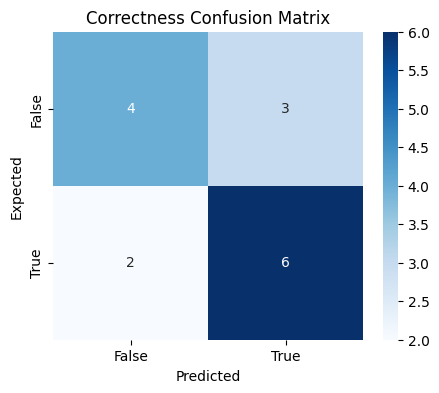

In [40]:
correctness_conf_matrix = confusion_matrix(df['expected_correctness'], df['predicted_correctness'])
plt.figure(figsize=(5,4))
sns.heatmap(correctness_conf_matrix, annot=True, fmt='d', xticklabels=['False', 'True'], yticklabels=['False', 'True'], cmap='Blues')
plt.title('Correctness Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Expected')
plt.show()

## Category Evaluation

Checking the model's performance regarding the prediction of the player's question's category

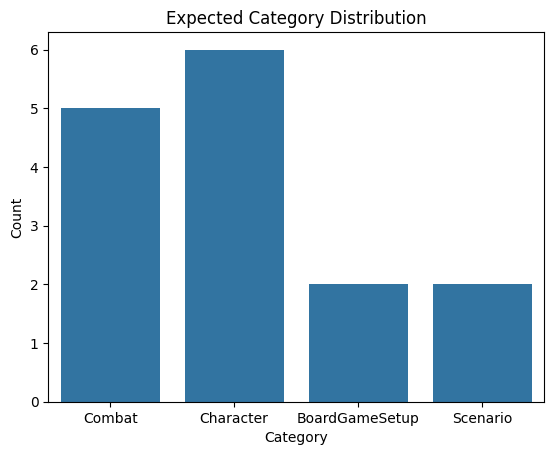

In [80]:
sns.countplot(
    data=df,
    x='expected_category'
)
plt.title('Expected Category Distribution')
plt.ylabel('Count')
plt.xlabel('Category')
plt.show()

In [56]:
report = classification_report(df['expected_category'], df['predicted_category'], zero_division=0, output_dict=True)
pd.DataFrame(report).T

,precision,recall,f1-score,support
BoardGameSetup,0.000000,0.000000,0.000000,2.000000
Character,1.000000,0.166667,0.285714,6.000000
Combat,0.571429,0.800000,0.666667,5.000000
Scenario,0.285714,1.000000,0.444444,2.000000
accuracy,0.466667,0.466667,0.466667,0.466667
macro avg,0.464286,0.491667,0.349206,15.000000
weighted avg,0.628571,0.466667,0.395767,15.000000


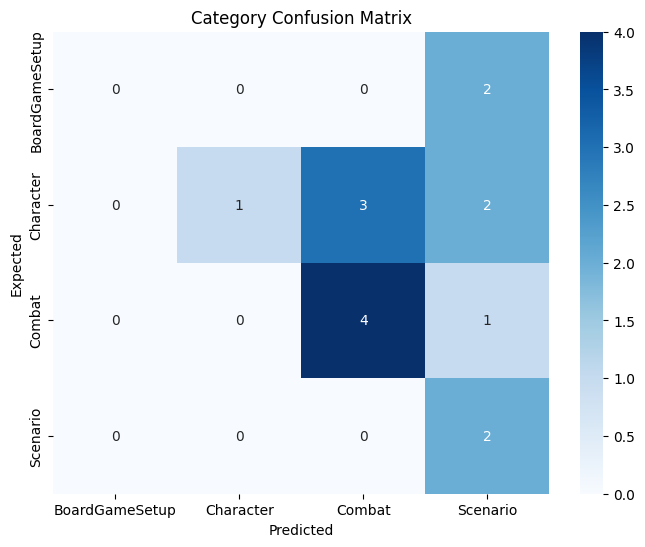

In [42]:
category_conf_matrix = confusion_matrix(df['expected_category'], df['predicted_category'])
categories = sorted(set(df['expected_category']))
plt.figure(figsize=(8,6))
sns.heatmap(category_conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('Expected')
plt.title('Category Confusion Matrix')
plt.show()

## Retrieval Score vs Correctness

Check if there is any correlation between low retrieval score and bad correctness prediction

In [69]:
df['correctness_correct'] = df['expected_correctness'] == df['predicted_correctness'] 

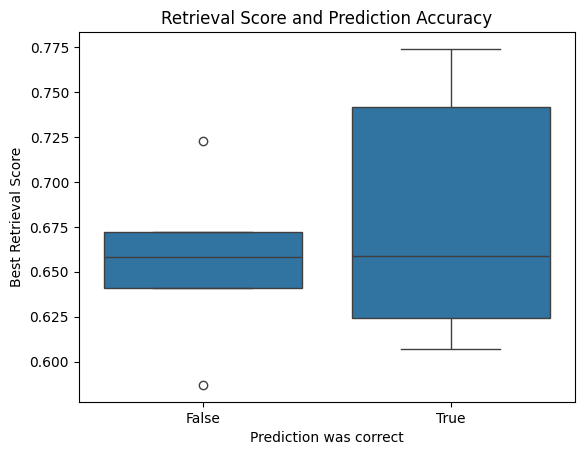

In [73]:
sns.boxplot(data=df, x='correctness_correct', y='best_retrieval_score')
plt.ylabel('Best Retrieval Score')
plt.xlabel('Prediction was correct')
plt.title('Retrieval Score and Prediction Accuracy')
plt.show()